Import Libraries and Constants

In [41]:
from transformers import TFAutoModel
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os

# Constants
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 80
EPOCHS = 100
NUM_CLASSES = 3 # Number of classes in your dataset
training_dir = "C:/Users/arfao/Desktop/intern_ship/train"
testing_dir = "C:/Users/arfao/Desktop/intern_ship/test"


In [42]:
# Data loading with preprocessing
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255  # Only rescale since augmentation is already done
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    directory=training_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

test_generator = test_datagen.flow_from_directory(
    directory=testing_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Found 2311 images belonging to 3 classes.
Found 431 images belonging to 3 classes.


In [43]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, GlobalAveragePooling1D

# Custom Encoder (same as before, no need to change here)
class CustomEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super(CustomEncoder, self).__init__(**kwargs)
        self.attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.attention(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


# Custom Transformer (Modified for Classification)
class CustomTransformer(tf.keras.Model):
    def __init__(self, embed_dim, num_heads, ff_dim, num_encoders, dropout_rate=0.1, **kwargs):
        super(CustomTransformer, self).__init__(**kwargs)
        # Only encoders are required for classification
        self.encoders = [CustomEncoder(embed_dim, num_heads, ff_dim, dropout_rate) for _ in range(num_encoders)]

    def call(self, inputs, training=False):
        enc_outputs = inputs
        for encoder in self.encoders:
            enc_outputs = encoder(enc_outputs, training=training)
        
        return enc_outputs  # Outputs from the final encoder


# Classification Head (Added for final classification)
class TransformerClassifier(tf.keras.Model):
    def __init__(self, embed_dim, num_heads, ff_dim, num_encoders, num_classes, dropout_rate=0.1, **kwargs):
        super(TransformerClassifier, self).__init__(**kwargs)
        # Transformer as feature extractor
        self.transformer = CustomTransformer(embed_dim, num_heads, ff_dim, num_encoders, dropout_rate)
        
        # Classification head
        self.pooling = GlobalAveragePooling1D()  # Pooling layer to reduce the sequence dimension
        self.fc1 = Dense(128, activation='relu')
        self.dropout = Dropout(0.2)
        self.fc2 = Dense(num_classes, activation='softmax')  # Final classification layer
    
    def call(self, inputs, training=False):
        # Get transformer outputs (embedding)
        transformer_output = self.transformer(inputs, training=training)
        
        # Classification head
        x = self.pooling(transformer_output)
        x = self.fc1(x)
        x = self.dropout(x, training=training)
        x = self.fc2(x)
        return x


Custom Vision Transformer Layer

In [44]:
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.initializers import RandomNormal

class PatchEmbedding(tf.keras.layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super(PatchEmbedding, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.projection = Dense(embed_dim, kernel_initializer=RandomNormal())

    def call(self, images):
        # Divide image into patches
        batch_size, height, width, channels = tf.shape(images)[0], images.shape[1], images.shape[2], images.shape[3]
        patch_h, patch_w = height // self.patch_size, width // self.patch_size
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, patch_h, patch_w, 1],
            strides=[1, patch_h, patch_w, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        # Flatten each patch and project into embedding dimension
        patches = tf.reshape(patches, [batch_size, -1, patch_h * patch_w * channels])
        return self.projection(patches)

class CustomTransformerLayer(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, num_encoders, dropout_rate=0.1, **kwargs):
        super(CustomTransformerLayer, self).__init__(**kwargs)
        self.transformer = CustomTransformer(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            num_encoders=num_encoders,
            dropout_rate=dropout_rate
        )

    def call(self, inputs, training=False):
        # Only pass inputs and training, and let Keras handle the rest
        return self.transformer(inputs, training=training)





Build the Model

In [45]:
# Build the Model
inputs = layers.Input(shape=IMAGE_SIZE + (3,))
preprocessed_inputs = inputs / 255.0

# Patch Embedding
patch_size = 16
embed_dim = 64
num_heads = 4
ff_dim = 128
num_encoders = 2

patch_embeddings = PatchEmbedding(patch_size=patch_size, embed_dim=embed_dim)(preprocessed_inputs)

# Transformer layer
transformer_outputs = CustomTransformerLayer(
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_encoders=num_encoders  # Removed num_decoders
)(patch_embeddings)

# Pooling and classification
x = layers.GlobalAveragePooling1D()(transformer_outputs)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create the model
model = models.Model(inputs=inputs, outputs=outputs)


Learning Rate Warmup and Decay Schedule

In [46]:
class WarmupAndDecaySchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, decay_steps, decay_rate):
        super(WarmupAndDecaySchedule, self).__init__()
        self.base_lr = tf.cast(base_lr, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.decay_steps = tf.cast(decay_steps, tf.float32)
        self.decay_rate = tf.cast(decay_rate, tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.base_lr * (step / self.warmup_steps)
        decay_lr = self.base_lr * tf.math.pow(self.decay_rate, (step - self.warmup_steps) / self.decay_steps)
        return tf.where(step < self.warmup_steps, warmup_lr, decay_lr)

    def get_config(self):
        # Provide configuration for serialization
        return {
            "base_lr": float(self.base_lr.numpy()),
            "warmup_steps": float(self.warmup_steps.numpy()),
            "decay_steps": float(self.decay_steps.numpy()),
            "decay_rate": float(self.decay_rate.numpy())
        }
# Define learning rate schedule
lr_schedule = WarmupAndDecaySchedule(
    base_lr=1e-4, warmup_steps=1000, decay_steps=5000, decay_rate=0.96
)

# Compile the model with the optimizer
optimizer = Adam(learning_rate=lr_schedule)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Training

In [47]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('./transformer_model&hist/120_model.keras', save_best_only=True)
]

# Train the Model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks
)

# Save Training History
with open('./transformer_model&hist/training_history_120_model.pkl', 'wb') as f:
    pickle.dump(history.history, f)


Epoch 1/100


c:\Users\arfao\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 344ms/step - accuracy: 0.3069 - loss: 1.3743 - val_accuracy: 0.0719 - val_loss: 1.4154
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step - accuracy: 0.3225 - loss: 1.2145 - val_accuracy: 0.4200 - val_loss: 1.0690
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step - accuracy: 0.3943 - loss: 1.0954 - val_accuracy: 0.6520 - val_loss: 1.0187
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 329ms/step - accuracy: 0.4130 - loss: 1.0812 - val_accuracy: 0.6682 - val_loss: 1.0020
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 328ms/step - accuracy: 0.4194 - loss: 1.0627 - val_accuracy: 0.7100 - val_loss: 0.9530
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 328ms/step - accuracy: 0.4649 - loss: 1.0351 - val_accuracy: 0.7262 - val_loss: 0.9124
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 333ms/step - accuracy: 0.4996 - loss: 1.0088 - val_accuracy: 0.7355 - val_loss: 0.8299
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step - accuracy: 0.5779 - loss: 0.9467 - val_accuracy

Evaluate the Model

In [48]:
# Evaluate the Model
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=-1)

accuracy = np.mean(y_pred == y_true)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step
Test Accuracy: 98.84%
Precision: 0.9829
Recall: 0.9917
F1 Score: 0.9872


Plot Accuracy and Loss

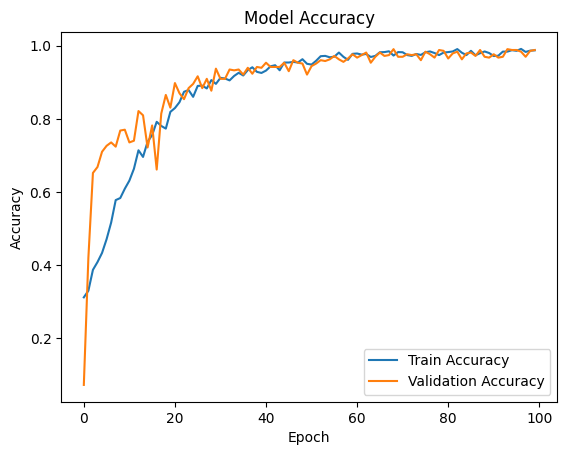

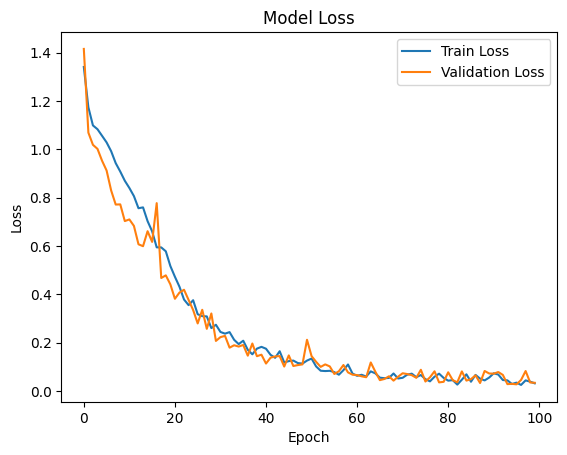

In [49]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Confusion Matrix

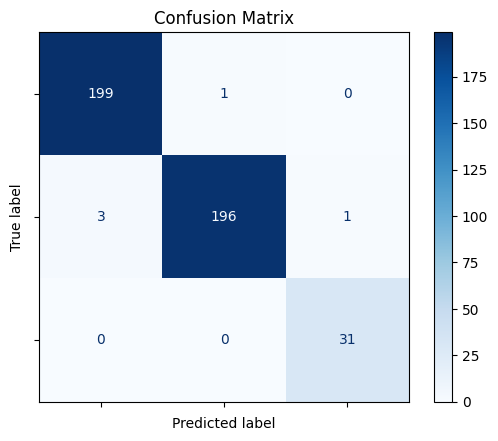

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Verify the class labels
actual_labels = list(test_generator.class_indices.keys())
predicted_labels = np.unique(np.concatenate((y_true, y_pred)))

# Handle missing labels
used_labels = [label for label in actual_labels if label in predicted_labels]

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=used_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
